<a href="https://colab.research.google.com/github/Vane-UNCP/tecemer-lab1/blob/main/SEMANA6/Ejercicio_04c_RNN_Descripcion_Imagenes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 4c — Redes Neuronales Recurrentes: Descripción de Imágenes (Image Captioning)
### Tecnologías Emergentes (ISO46B) — Material complementario de comprensión conceptual

Notebook **autocontenido** para **Google Colab** (`Entorno de ejecución > Ejecutar todas`). Usa **PyTorch + Hugging Face Transformers** y un modelo preentrenado de descripción de imágenes; las imágenes de ejemplo se descargan por código.

**Objetivo:** entender la arquitectura **encoder–decoder**, que combina TODO lo visto hasta ahora: una **CNN** (Notebook 3a) que "lee" la imagen, y un **decodificador secuencial** (con ideas de RNN/atención, Notebook 4a) que "escribe" la descripción palabra por palabra.

## 0. Configuración inicial

In [14]:
!pip install -q transformers

In [15]:
import io
import requests
import matplotlib.pyplot as plt

import torch
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image

torch.manual_seed(101)
dispositivo = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo:", dispositivo)

Dispositivo: cpu


## 1. La arquitectura encoder–decoder para describir imágenes

Describir una imagen en lenguaje natural combina dos tareas que ya vimos por separado:

```
   IMAGEN                         "a dog running through
     │                             a grassy field"
     ▼                                    ▲
┌──────────┐   vector de      ┌──────────────────────┐
│  ENCODER │   características │      DECODER          │
│  (CNN /  │ ───────────────▶ │  (RNN/LSTM o           │
│  Vision   │                  │   Transformer, genera  │
│Transformer)│                  │   una palabra a la vez)│
└──────────┘                  └──────────────────────┘
```

- El **encoder** (una CNN, como la del Notebook 3a, o su equivalente moderno, un Vision Transformer) convierte la imagen en un vector (o un conjunto de vectores) que resume su contenido visual.
- El **decoder** (una RNN/LSTM, como la del Notebook 4a, o su equivalente moderno, un Transformer) genera la descripción **palabra por palabra**, usando en cada paso: (a) las palabras ya generadas, y (b) un mecanismo de **atención** que le permite "mirar" distintas partes de la imagen según qué palabra está generando.

Los modelos clásicos de este tipo (p. ej. *Show, Attend and Tell*, 2015) usaban exactamente CNN + LSTM + atención. Los modelos modernos (como el que usaremos aquí, **BLIP**) reemplazan la LSTM por un Transformer, pero la idea de fondo —encoder visual + decoder secuencial con atención— es la misma.

## 2. Cargar un modelo preentrenado (transfer learning, otra vez)

Entrenar un modelo de captioning desde cero requiere datasets con **cientos de miles de pares imagen–descripción** (como COCO Captions o Flickr30k) y varios días de GPU. En su lugar, cargamos **BLIP**, un modelo ya entrenado para esta tarea.

In [16]:
NOMBRE_MODELO = "Salesforce/blip-image-captioning-base"

procesador = BlipProcessor.from_pretrained(NOMBRE_MODELO)
modelo = BlipForConditionalGeneration.from_pretrained(NOMBRE_MODELO).to(dispositivo)
modelo.eval()

n_parametros = sum(p.numel() for p in modelo.parameters())
print(f"Modelo cargado: {NOMBRE_MODELO}")
print(f"Parámetros totales: {n_parametros:,}")

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Modelo cargado: Salesforce/blip-image-captioning-base
Parámetros totales: 223,971,644


## 3. Descargar imágenes de ejemplo

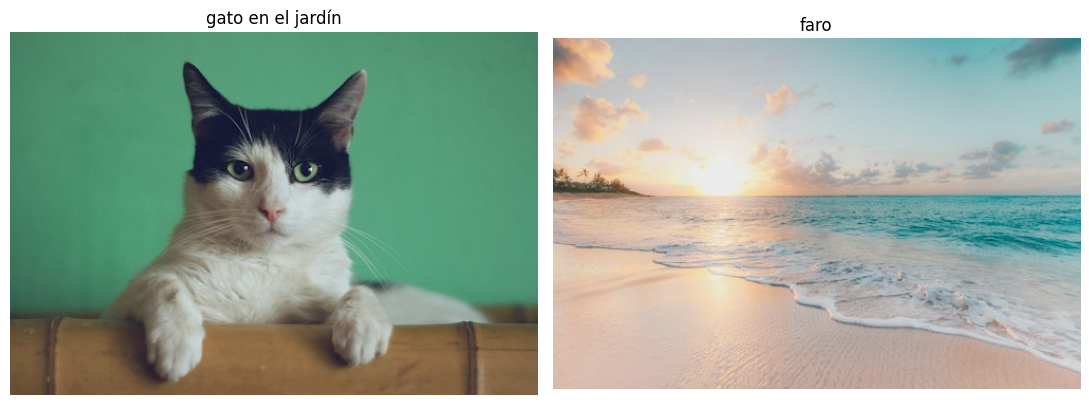

In [17]:
def cargar_imagen(url):
    # Se agrega un User-Agent realista para evitar que los servidores bloqueen la petición
    cabeceras = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"}
    respuesta = requests.get(url, headers=cabeceras, timeout=20)
    respuesta.raise_for_status() # Asegura que la descarga fue exitosa
    return Image.open(io.BytesIO(respuesta.content)).convert("RGB")

urls_ejemplo = {
    "gato en el jardín": "https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?w=500",
    "faro": "https://images.unsplash.com/photo-1507525428034-b723cf961d3e?w=500",
}
imagenes = {nombre: cargar_imagen(url) for nombre, url in urls_ejemplo.items()}

fig, ejes = plt.subplots(1, len(imagenes), figsize=(11, 5))
for ax, (nombre, img) in zip(ejes, imagenes.items()):
    ax.imshow(img)
    ax.set_title(nombre)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Generar descripciones (captioning "no condicionado")

[gato en el jardín] -> a cat sitting on top of a wooden box
[faro] -> a beach with a sunset in the background


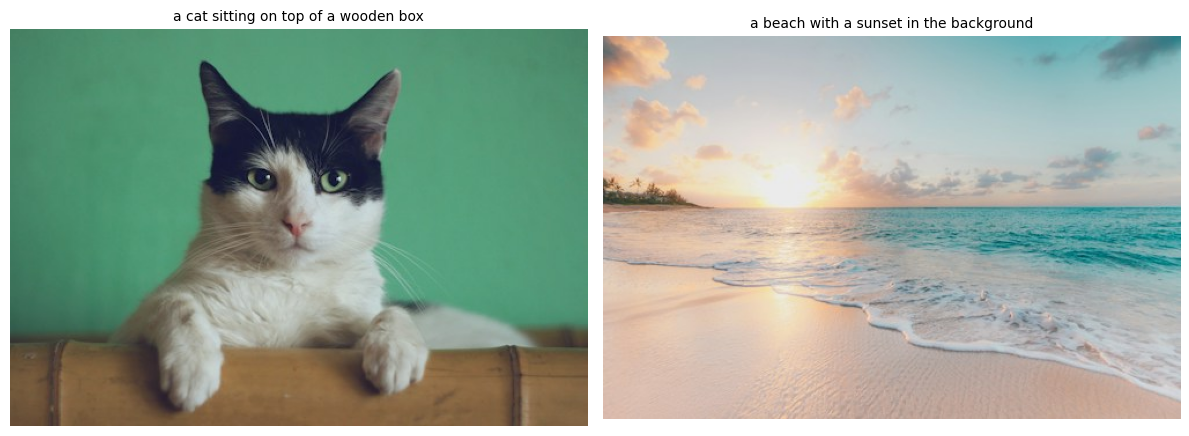

In [18]:
def generar_descripcion(imagen, texto_previo=None, max_tokens=30):
    if texto_previo:
        entradas = procesador(imagen, texto_previo, return_tensors="pt").to(dispositivo)
    else:
        entradas = procesador(imagen, return_tensors="pt").to(dispositivo)
    with torch.no_grad():
        salida = modelo.generate(**entradas, max_new_tokens=max_tokens)
    return procesador.decode(salida[0], skip_special_tokens=True)

fig, ejes = plt.subplots(1, len(imagenes), figsize=(12, 6))
for ax, (nombre, img) in zip(ejes, imagenes.items()):
    descripcion = generar_descripcion(img)
    ax.imshow(img)
    ax.set_title(descripcion, fontsize=10, wrap=True)
    ax.axis("off")
    print(f"[{nombre}] -> {descripcion}")
plt.tight_layout()
plt.show()

## 5. Captioning "condicionado": darle una pista al modelo

Además de generar una descripción libre, BLIP puede **completar** un texto inicial que nosotros le damos — el decoder sigue funcionando palabra por palabra, pero ahora parte de un contexto textual además del visual.

In [19]:
imagen_prueba = imagenes["gato en el jardín"]

prefijos = ["a cute kitten", "the color of the cat"]
for prefijo in prefijos:
    completado = generar_descripcion(imagen_prueba, texto_previo=prefijo)
    print(f"'{prefijo}' -> '{completado}'")

'a cute kitten' -> 'a cute kitten is sitting on a wooden box'
'the color of the cat' -> 'the color of the cat is green'


## 6. Estrategias de decodificación: greedy vs. beam search

En cada paso, el decoder produce una distribución de probabilidad sobre el siguiente token. ¿Cómo se elige la palabra final?

- **Greedy (voraz)**: en cada paso, elige siempre la palabra más probable. Es rápido, pero puede quedar atrapado en una descripción subóptima.
- **Beam search**: mantiene varias secuencias candidatas en paralelo (el "ancho de haz") y al final elige la de mayor probabilidad conjunta — suele producir descripciones más coherentes.

In [20]:
def generar_con_estrategia(imagen, num_beams=1, max_tokens=30):
    entradas = procesador(imagen, return_tensors="pt").to(dispositivo)
    with torch.no_grad():
        salida = modelo.generate(**entradas, max_new_tokens=max_tokens, num_beams=num_beams)
    return procesador.decode(salida[0], skip_special_tokens=True)

for num_beams, nombre_estrategia in [(1, "greedy"), (3, "beam search (3 haces)")]:
    descripcion = generar_con_estrategia(imagen_prueba, num_beams=num_beams)
    print(f"{nombre_estrategia}: '{descripcion}'")

greedy: 'a cat sitting on top of a wooden box'
beam search (3 haces): 'a black and white cat sitting on top of a wooden box'


**Nota:** con imágenes simples, ambas estrategias suelen coincidir o dar resultados muy parecidos; la diferencia se nota más en imágenes ambiguas o descripciones largas, donde `beam search` explora más alternativas antes de decidir.

## 7. Resumen

- El **captioning de imágenes** combina un encoder visual (CNN / Vision Transformer, Notebook 3a) con un decoder secuencial (RNN/LSTM / Transformer, Notebook 4a) — es el ejemplo más directo de cómo se **combinan** arquitecturas de visión y de lenguaje.
- El mecanismo de **atención** permite que el decoder consulte distintas regiones de la imagen en cada paso de generación, en lugar de depender de un único vector resumen fijo.
- Igual que en los Notebooks 3b y 4c, usar un modelo **preentrenado** (transfer learning) es la forma práctica de trabajar con estas arquitecturas sin necesitar datasets ni cómputo masivos.
- La estrategia de **decodificación** (greedy vs. beam search vs. muestreo) es una decisión independiente de la arquitectura, y afecta directamente la calidad del texto generado.
